# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
df = pd.read_csv('../data/Instagram_Analytics.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (29999, 23)


,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,...,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,2,1,22,1639,2616,0.0531,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,0,7,0,2877,3171,0.0309,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,8,5,21,5350,8503,0.0221,155,112,9,low


In [6]:
print(df.dtypes)
print(f'\nNulls: {df.isnull().sum().sum()}')
print(f'\nTarget distribution:')
print(df['performance_bucket_label'].value_counts())

post_id                         str
account_id                    int64
account_type                    str
follower_count                int64
media_type                      str
content_category                str
traffic_source                  str
has_call_to_action            int64
post_datetime                   str
post_date                       str
post_hour                     int64
day_of_week                     str
likes                         int64
comments                      int64
shares                        int64
saves                         int64
reach                         int64
impressions                   int64
engagement_rate             float64
followers_gained              int64
caption_length                int64
hashtags_count                int64
performance_bucket_label        str
dtype: object

Nulls: 0

Target distribution:
performance_bucket_label
viral     7500
high      7500
low       7500
medium    7499
Name: count, dtype: int64


## Distribution of target classes

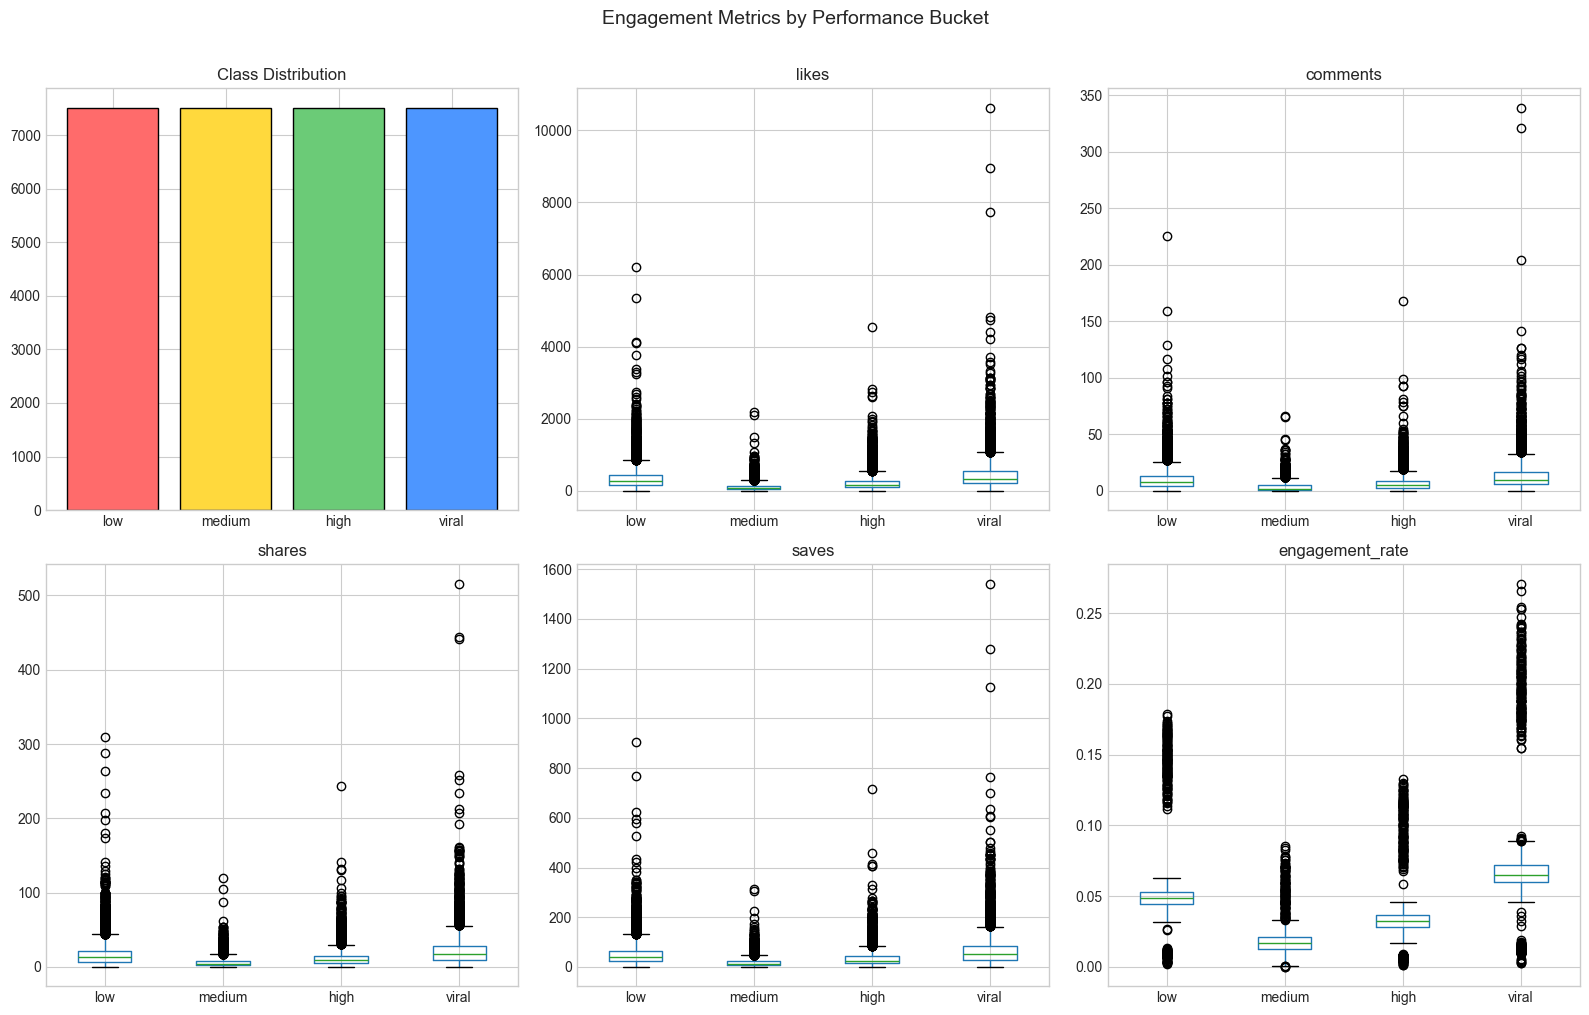

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

order = ['low','medium','high','viral']
counts = df['performance_bucket_label'].value_counts().reindex(order)
axes[0,0].bar(order, counts.values, color=['#FF6B6B','#FFD93D','#6BCB77','#4D96FF'], edgecolor='k')
axes[0,0].set_title('Class Distribution')

for ax, col in zip(axes.flat[1:], ['likes','comments','shares','saves','engagement_rate']):
    df.boxplot(column=col, by='performance_bucket_label', ax=ax, 
               positions=[0,1,2,3])
    ax.set_title(col)
    ax.set_xlabel('')
    plt.sca(ax); plt.xticks([0,1,2,3], order)
plt.suptitle('Engagement Metrics by Performance Bucket', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

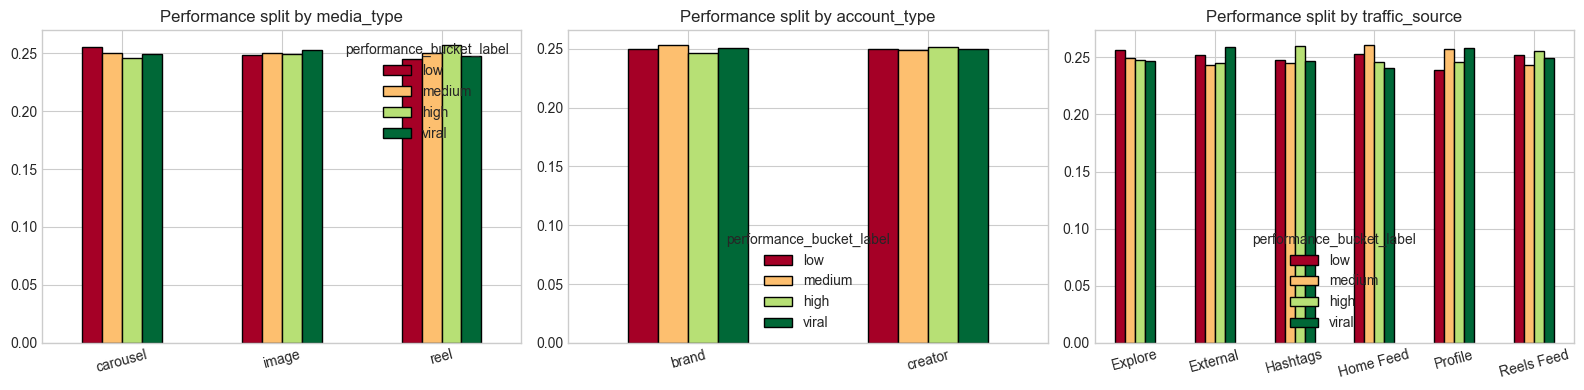

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['media_type','account_type','traffic_source']):
    ct = pd.crosstab(df[col], df['performance_bucket_label'], normalize='index')[order]
    ct.plot(kind='bar', ax=ax, colormap='RdYlGn', edgecolor='k')
    ax.set_title(f'Performance split by {col}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

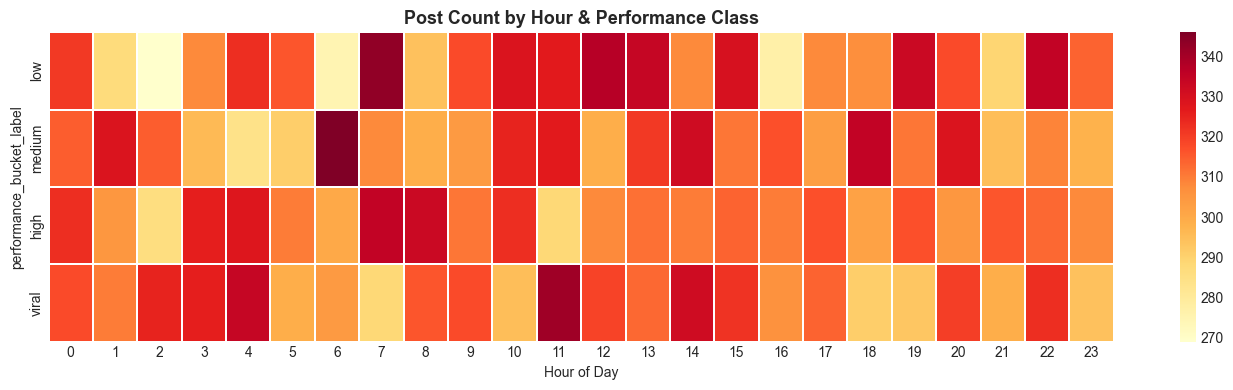

In [8]:
# Posting hour heatmap
hour_perf = df.groupby(['post_hour','performance_bucket_label']).size().unstack(fill_value=0)[order]
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(hour_perf.T, cmap='YlOrRd', ax=ax, linewidths=0.3)
ax.set_title('Post Count by Hour & Performance Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
plt.tight_layout()
plt.show()

## Correlation matrix

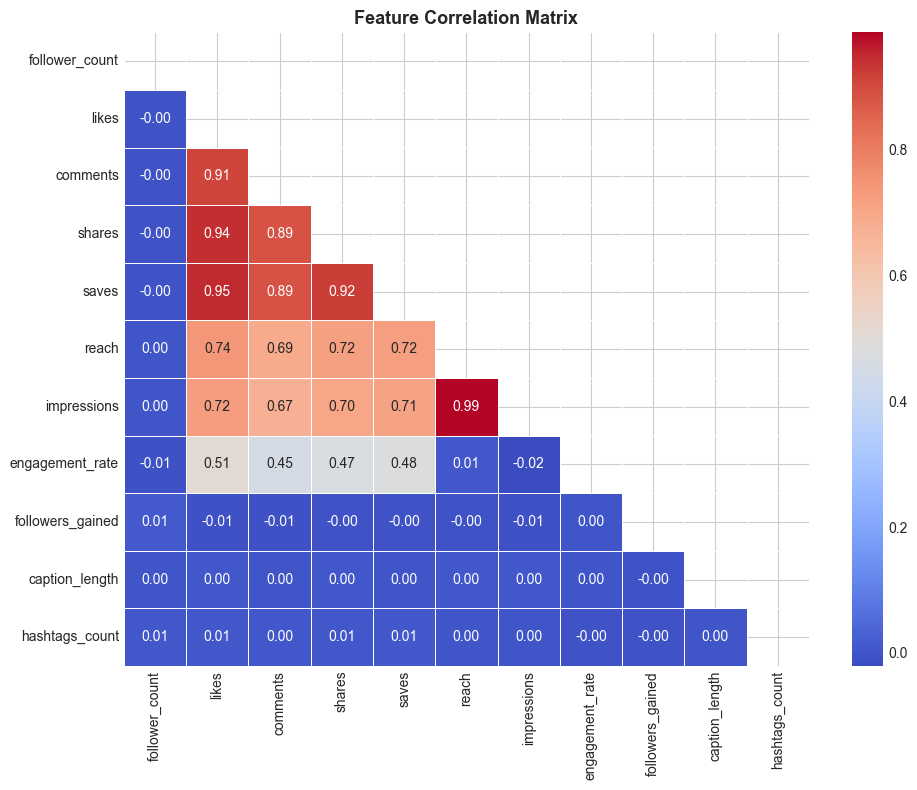

In [9]:
num_cols = ['follower_count','likes','comments','shares','saves','reach','impressions',
            'engagement_rate','followers_gained','caption_length','hashtags_count']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.4)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()